# Calibration and counterfactual fraud experiments

**Goal.** Fit a calibration profile against reference data, then run a controlled counterfactual intervention. The workflow keeps source truth immutable and records provenance for both artifacts.

**Audience.** Data/ML scientists, fraud analysts, platform engineers, and researchers.

**Prerequisites.** Python 3.12+, a clean checkout, and the base FraudTwin install. The workflow is deterministic and runs offline; service integrations are deliberately out of scope here.

**Source size.** 1,000–10,000 logical payments. Every section writes only compact summaries, manifests, or fingerprints to a temporary directory.

**Interpretation.** Synthetic evidence demonstrates mechanics and invariants, not production prevalence or model performance guarantees.


## Calibration against reference data



In [1]:
from pathlib import Path

import polars as pl

from fraudtwin.calibration import (
    ReferenceDataset,
    apply_calibration_profile,
    fit_calibration_profile,
    load_calibration_profile,
    write_calibration_profile,
)
from fraudtwin.config import load_config
from fraudtwin.generation import generate
from fraudtwin.reproducibility import sha256_json

root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "configs" / "minimal.yaml").is_file()),
    Path.cwd(),
)
base = load_config(root / "configs" / "minimal.yaml")
config = base.model_copy(
    update={"payments": base.payments.model_copy(update={"daily_target": 1000})}
)
data = generate(config, write=False)
payments = data.behavior.payments
print({"run_id": data.run_id, "payments": len(payments)})
assert len(payments) >= 1000

{'run_id': 'RUN-f0981dbfd03c1bf5', 'payments': 1000}


In [2]:
reference = pl.DataFrame(
    [
        {"amount": p.amount, "event_time": p.initiated_at, "customer_id": p.payer_account_id}
        for p in payments
    ]
)
reference_summary = pl.DataFrame(
    {
        "metric": [
            "payments",
            "customers",
            "first event",
            "last event",
            "minimum amount",
            "median amount",
            "average amount",
            "maximum amount",
        ],
        "value": [
            str(reference.height),
            str(reference["customer_id"].n_unique()),
            reference["event_time"].min().strftime("%Y-%m-%d %H:%M UTC"),
            reference["event_time"].max().strftime("%Y-%m-%d %H:%M UTC"),
            f"{reference['amount'].min():.2f}",
            f"{reference['amount'].median():.2f}",
            f"{reference['amount'].mean():.2f}",
            f"{reference['amount'].max():.2f}",
        ],
    }
)
print(reference_summary)
assert reference.height >= 1000

shape: (8, 2)
┌────────────────┬──────────────────────┐
│ metric         ┆ value                │
│ ---            ┆ ---                  │
│ str            ┆ str                  │
╞════════════════╪══════════════════════╡
│ payments       ┆ 1000                 │
│ customers      ┆ 15                   │
│ first event    ┆ 2026-01-01 00:01 UTC │
│ last event     ┆ 2026-01-01 23:57 UTC │
│ minimum amount ┆ 1.00                 │
│ median amount  ┆ 11.43                │
│ average amount ┆ 19.87                │
│ maximum amount ┆ 279.76               │
└────────────────┴──────────────────────┘


In [3]:
ref = ReferenceDataset(
    reference,
    source_fingerprint=sha256_json(reference.to_dicts()),
    schema_fingerprint=sha256_json([(n, str(t)) for n, t in reference.schema.items()]),
)
profile = fit_calibration_profile(ref, seed=42)
print(
    {
        "profile_id": profile.profile_id,
        "summaries": len(profile.summaries),
        "distributions": len(profile.distributions),
    }
)

{'profile_id': 'CAL-f25cf58a1938beae78ce', 'summaries': 10, 'distributions': 2}


In [4]:
summary_table = [
    {"name": s.name, "fields": s.fields, "available": s.available} for s in profile.summaries
]
display(pl.DataFrame(summary_table))
assert any(s["name"] == "amount_distribution" for s in summary_table)

name,fields,available
str,list[str],bool
"""amount_distribution""","[""amount""]",true
"""seasonality""","[""event_time""]",true
"""customer_activity""","[""customer_id""]",true
"""transaction_count""","[""customer_id""]",true
"""inter_arrival""","[""event_time""]",true
"""merchant_frequency""","[""merchant_category""]",true
"""account_balance""","[""account_balance""]",true
"""graph_statistics""","[""payer_account_id"", ""payee_account_id""]",true
"""campaign_statistics""","[""campaign_id""]",true


In [5]:
amount = next(d for d in profile.distributions if d.name == "amount")
print({"quantiles": amount.quantiles, "minimum": amount.minimum, "maximum": amount.maximum})
assert amount.minimum is not None and amount.maximum is not None

{'quantiles': (1.0, 2.67, 5.04, 11.44, 25.81, 44.11, 279.76), 'minimum': 1.0, 'maximum': 279.76}


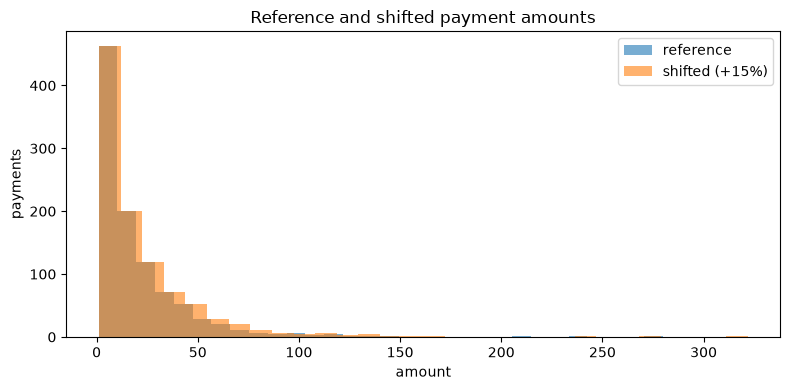

In [6]:
shifted = reference.with_columns((pl.col("amount") * 1.15).alias("amount"))
try:
    import matplotlib.pyplot as plt

    fig, axis = plt.subplots(figsize=(8, 4))
    axis.hist(reference["amount"].to_list(), bins=30, alpha=0.6, label="reference")
    axis.hist(shifted["amount"].to_list(), bins=30, alpha=0.6, label="shifted (+15%)")
    axis.set(title="Reference and shifted payment amounts", xlabel="amount", ylabel="payments")
    axis.legend()
    fig.tight_layout()
    plt.show()
    plt.close(fig)
except ImportError:
    print("Install matplotlib to render the amount-shift plot.")
assert shifted["amount"].mean() > reference["amount"].mean()

In [7]:
resolved = apply_calibration_profile(profile, seed=42)
print(
    {"enabled": resolved.enabled, "profile_id": resolved.profile_id, "streams": resolved.stream_ids}
)
assert resolved.enabled and resolved.profile_id == profile.profile_id

{'enabled': True, 'profile_id': 'CAL-f25cf58a1938beae78ce', 'streams': ('milestone-16:calibrated-generation',)}


In [8]:
from tempfile import TemporaryDirectory

with TemporaryDirectory() as tmp:
    path = write_calibration_profile(profile, Path(tmp) / "profile.yaml")
    loaded = load_calibration_profile(path)
print({"loaded": loaded.profile_id, "source_rows": loaded.provenance.row_count})
assert loaded.profile_id == profile.profile_id

{'loaded': 'CAL-f25cf58a1938beae78ce', 'source_rows': 1000}


In [9]:
artifact = {
    "run_id": data.run_id,
    "profile_id": profile.profile_id,
    "source": profile.provenance.source_fingerprint,
    "rows": profile.provenance.row_count,
}
artifact["fingerprint"] = sha256_json(artifact)
print(
    {
        "run_id": artifact["run_id"],
        "profile_id": artifact["profile_id"],
        "rows": artifact["rows"],
        "fingerprint": f"{artifact['fingerprint'][:12]}...",
    }
)

{'run_id': 'RUN-f0981dbfd03c1bf5', 'profile_id': 'CAL-f25cf58a1938beae78ce', 'rows': 1000, 'fingerprint': '9eee750347de...'}


In [10]:
assert artifact["fingerprint"] == sha256_json(
    {k: v for k, v in artifact.items() if k != "fingerprint"}
)
print("Calibration is versioned, deterministic, and append-only.")

Calibration is versioned, deterministic, and append-only.


## Counterfactual fraud experiment



In [11]:
from pathlib import Path

from fraudtwin.config import load_config
from fraudtwin.generation import generate
from fraudtwin.reproducibility import sha256_json

base = load_config(root / "configs" / "benchmarks" / "m14-counterfactual-v1.yaml")
config = base
data = generate(config, write=False)
source_ids = tuple(p.payment_id for p in data.behavior.payments)
source_fp = sha256_json(source_ids)
cf = data.behavior.counterfactual
print(
    {"run_id": data.run_id, "payments": len(source_ids), "counterfactual_id": cf.counterfactual_id}
)
assert cf is not None

{'run_id': 'RUN-5ee94cd664213302', 'payments': 840, 'counterfactual_id': 'CF-RUN-5ee94cd664213302'}


In [12]:
print(
    {
        "original": len(cf.original_payments),
        "modified": len(cf.modified_payments),
        "accepted": sum(x.status == "ACCEPTED" for x in cf.change_sets),
        "rejected": len(cf.rejected),
    }
)
assert cf.change_sets

{'original': 3, 'modified': 3, 'accepted': 3, 'rejected': 0}


In [13]:
assert cf.change_sets
print("Counterfactual changes:")
for change in cf.change_sets:
    status = str(change.status).replace("_", " ").title()
    fields = ", ".join(change.changed_fields) or "none"
    print(
        f"  {change.objective} - {status}; "
        f"distance={change.effective_distance:.3f}; changed: {fields}"
    )

Counterfactual changes:
  F01 - Accepted; distance=1.000; changed: amount
  F03 - Accepted; distance=1.000; changed: beneficiary
  F04 - Accepted; distance=1.000; changed: beneficiary


In [14]:
accepted = [x for x in cf.change_sets if x.status == "ACCEPTED"]
print(
    {
        "accepted_objectives": [x.objective for x in accepted],
        "derived_ids": len(cf.modified_payments),
    }
)
assert all(x.derived_payment_id != x.source_payment_id for x in accepted)

{'accepted_objectives': ['F01', 'F03', 'F04'], 'derived_ids': 3}


In [15]:
pairs = list(zip(cf.original_payments, cf.modified_payments, strict=False))
print({"paired": len(pairs), "amount_changes": sum(a.amount != b.amount for a, b in pairs)})

{'paired': 3, 'amount_changes': 1}


In [16]:
from collections import Counter

counts = Counter(x.objective for x in cf.change_sets)
print(dict(counts))
assert sum(counts.values()) == len(cf.change_sets)

{'F01': 1, 'F03': 1, 'F04': 1}


In [17]:
source_after = sha256_json(tuple(p.payment_id for p in data.behavior.payments))
print({"before": f"{source_fp[:12]}...", "after": f"{source_after[:12]}..."})
assert source_after == source_fp

{'before': 'c7085b45e14d...', 'after': 'c7085b45e14d...'}


In [18]:
print(
    {"rejections": [{"objective": x.objective, "reason": x.rejection_reason} for x in cf.rejected]}
)

{'rejections': []}


In [19]:
manifest = {
    "counterfactual_id": cf.counterfactual_id,
    "source_run_id": data.run_id,
    "accepted": len(cf.modified_payments),
    "rejected": len(cf.rejected),
    "source_fingerprint": source_fp,
}
manifest["fingerprint"] = sha256_json(manifest)
print(
    {
        "counterfactual_id": manifest["counterfactual_id"],
        "accepted": manifest["accepted"],
        "rejected": manifest["rejected"],
        "fingerprint": f"{manifest['fingerprint'][:12]}...",
    }
)

{'counterfactual_id': 'CF-RUN-5ee94cd664213302', 'accepted': 3, 'rejected': 0, 'fingerprint': '9856785e73ec...'}


In [20]:
assert manifest["fingerprint"] == sha256_json(
    {k: v for k, v in manifest.items() if k != "fingerprint"}
)
print("The intervention sidecar changes derived records only; source truth is unchanged.")

The intervention sidecar changes derived records only; source truth is unchanged.


## Verification and next step

Re-run the offline cells from a clean checkout and compare the printed fingerprints. For service-backed publication, continue with the relevant integration runbook after this notebook; do not treat synthetic metrics as a deployment SLO.
